# PCA — TensorFlow (CPU Tensor Ops)

## Model: Principal Component Analysis (Dimensionality Reduction)
- **Dataset**: Fashion-MNIST — 60,000 train / 10,000 test, 784 features (28×28 flattened), 10 classes
- **Task**: Compress 784 features while retaining maximum variance
- **Framework showcase**: Eager-mode vs Graph-mode — `tf.function`-compiled PCA fit vs eager execution

## CPU Tensor Strategy
- TF 2.11+ dropped native Windows GPU support — all ops run on CPU
- Same eigendecomposition algorithm as NF/PyTorch, but using TF eager-mode tensor ops
- Key TF translations:
  - `X.T @ X` → `tf.transpose(X) @ X` (no `.T` property)
  - `np.argsort(eigenvalues)[::-1]` → `tf.argsort(eigenvalues, direction='DESCENDING')`
  - `eigenvectors[:, idx]` → `tf.gather(eigenvectors, idx, axis=1)`
  - `result[bool_mask]` → `tf.boolean_mask(result, mask)`
- float32 for consistency with PyTorch comparisons

## Evaluation Strategy
- **Intrinsic**: Explained variance ratio, reconstruction error (MSE)
- **Extrinsic**: Downstream KNN classifier accuracy at different component counts
- **Component counts**: [10, 25, 50, 100, 150, 200]

In [1]:
# Step 1: Imports, Configuration, Data Loading, PCA Class

import numpy as np
import pickle
import sys
import os
import tensorflow as tf

sys.path.append('../..')

from sklearn.neighbors import KNeighborsClassifier
from utils.data_loader import load_processed_data
from utils.visualization import (plot_scree, plot_reconstruction_grid,
                                  plot_pca_components, plot_component_accuracy)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuration
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
N_COMPONENTS_LIST = [10, 25, 50, 100, 150, 200]
IMAGE_SHAPE = (28, 28)

tf.random.set_seed(RANDOM_STATE)


class PCATf:
    """
    PCA via eigendecomposition using TensorFlow CPU tensors.

    Same algorithm as NF PCAFromScratch and PyTorch PCAGpu, but
    all heavy ops (covariance, eigendecomposition, projection) use
    TF eager-mode tensor operations on CPU.

    TF 2.11+ dropped native Windows GPU support, so all ops run
    on CPU. float32 for consistency with PyTorch comparisons.

    Key TF translations:
        np.linalg.eigh → tf.linalg.eigh
        X.T @ X → tf.transpose(X) @ X (no .T property)
        eigenvectors[:, idx] → tf.gather(eigenvectors, idx, axis=1)

    Args:
        n_components: Number of principal components to keep.
    """

    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components_ = None        # (k, d) tensor — top k eigenvectors (rows)
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None              # (d,) tensor
        self.n_components_ = None

    def fit(self, X):
        """
        Compute principal components on CPU TF tensors.

        Args:
            X: (n, d) TF tensor, float32
        Returns:
            self
        """
        n, d = X.shape

        # Step 1: Center
        self.mean_ = tf.reduce_mean(X, axis=0)
        X_centered = X - self.mean_

        # Step 2: Covariance matrix — (d, d) on CPU
        # tf.transpose required (no .T property on TF tensors)
        cov = tf.transpose(X_centered) @ X_centered / n

        # Step 3: Eigendecomposition on CPU
        # tf.linalg.eigh returns ascending order (same as numpy/torch)
        eigenvalues, eigenvectors = tf.linalg.eigh(cov)

        # Reverse to descending (largest variance first)
        idx = tf.argsort(eigenvalues, direction='DESCENDING')
        eigenvalues = tf.gather(eigenvalues, idx)
        eigenvectors = tf.gather(eigenvectors, idx, axis=1)

        # Step 4: Keep top k
        k = self.n_components if self.n_components is not None else d
        self.n_components_ = k
        self.components_ = tf.transpose(eigenvectors[:, :k])  # (k, d)
        self.explained_variance_ = eigenvalues[:k]

        total_var = tf.reduce_sum(eigenvalues)
        self.explained_variance_ratio_ = eigenvalues[:k] / total_var

        # Full spectrum for scree plots (as numpy)
        self._all_variance_ratio = (eigenvalues / total_var).numpy()

        return self

    def transform(self, X):
        """Project to reduced space on CPU TF tensors."""
        return (X - self.mean_) @ tf.transpose(self.components_)

    def inverse_transform(self, X_reduced):
        """Reconstruct from reduced representation on CPU TF tensors."""
        return X_reduced @ self.components_ + self.mean_


# Load preprocessed Fashion-MNIST
X_train_np, X_test_np, y_train, y_test, meta = load_processed_data('pca')

# Load scaler for reconstruction visualizations
with open('../../data/processed/pca/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Convert to TF tensors (float32, CPU)
X_train = tf.constant(X_train_np, dtype=tf.float32)
X_test = tf.constant(X_test_np, dtype=tf.float32)

print("=" * 60)
print(f"PCA Pipeline — {FRAMEWORK}")
print("=" * 60)
print(f"[1/8] Data loaded + PCATf defined")
print(f"  Train: {tuple(X_train.shape)}, Test: {tuple(X_test.shape)}")
print(f"  Device: CPU (TF 2.11+ dropped native Windows GPU)")
print(f"  Dtype: {X_train.dtype.name}")
print(f"  Classes: {meta['n_classes']} — {', '.join(meta['class_names'])}")
print(f"  Scaler: mean shape={scaler['mean'].shape}, std shape={scaler['std'].shape}")

PCA Pipeline — TensorFlow
[1/8] Data loaded + PCATf defined
  Train: (60000, 784), Test: (10000, 784)
  Device: CPU (TF 2.11+ dropped native Windows GPU)
  Dtype: float32
  Classes: 10 — T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Bag, Sneaker, Ankle boot
  Scaler: mean shape=(784,), std shape=(784,)


[2/8] Full PCA fitted (TF eigendecomposition)
  Components: 784
  Top 10 explain: 62.2%
  90% variance at: 137 components
  95% variance at: 256 components


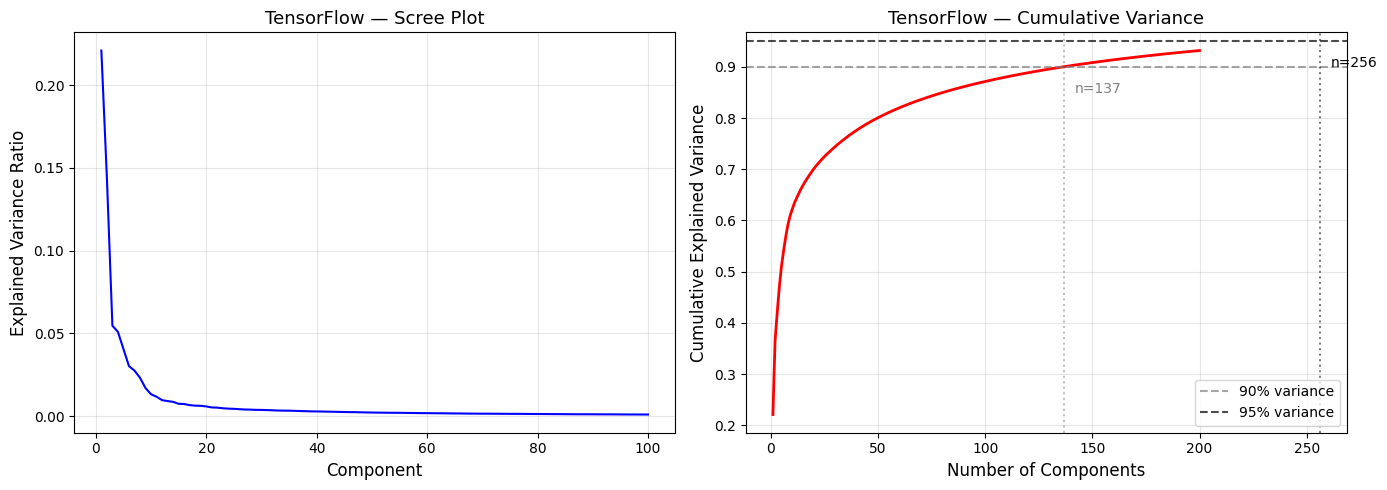

In [2]:
# Step 2: Fit full PCA + scree plot

# Fit with all components to get full eigenvalue spectrum
pca_full = PCATf(n_components=None)
pca_full.fit(X_train)

print("=" * 60)
print("[2/8] Full PCA fitted (TF eigendecomposition)")
print("=" * 60)
print(f"  Components: {pca_full.n_components_}")
print(f"  Top 10 explain: {sum(pca_full._all_variance_ratio[:10]):.1%}")
print(f"  90% variance at: {np.searchsorted(np.cumsum(pca_full._all_variance_ratio), 0.90) + 1} components")
print(f"  95% variance at: {np.searchsorted(np.cumsum(pca_full._all_variance_ratio), 0.95) + 1} components")

# Scree plot — _all_variance_ratio is already numpy from fit()
plot_scree(pca_full._all_variance_ratio, FRAMEWORK,
           save_path=f'{RESULTS_DIR}/scree_plot.png')

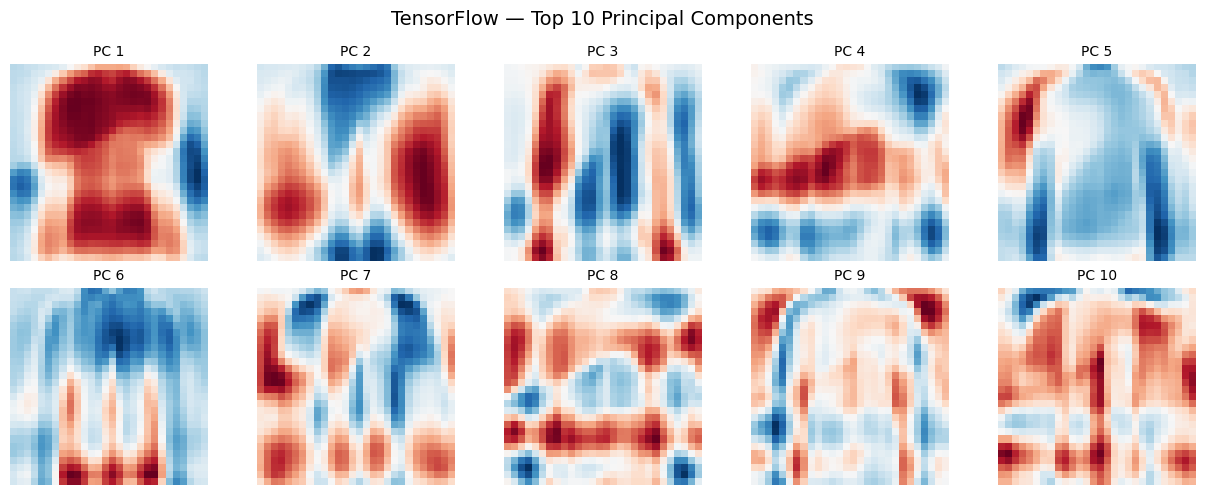

[3/8] Principal components visualized
  PC1 explains: 22.1%
  PC2 explains: 14.4%
  PC10 explains: 1.3%


In [3]:
# Step 3: Visualize top principal components as images

# components_ is a TF tensor — .numpy() for visualization
plot_pca_components(pca_full.components_.numpy(), IMAGE_SHAPE, n_components=10,
                    framework=FRAMEWORK, save_path=f'{RESULTS_DIR}/principal_components.png')

ev_ratio = pca_full.explained_variance_ratio_.numpy()
print("=" * 60)
print("[3/8] Principal components visualized")
print("=" * 60)
print(f"  PC1 explains: {ev_ratio[0]:.1%}")
print(f"  PC2 explains: {ev_ratio[1]:.1%}")
print(f"  PC10 explains: {ev_ratio[9]:.1%}")

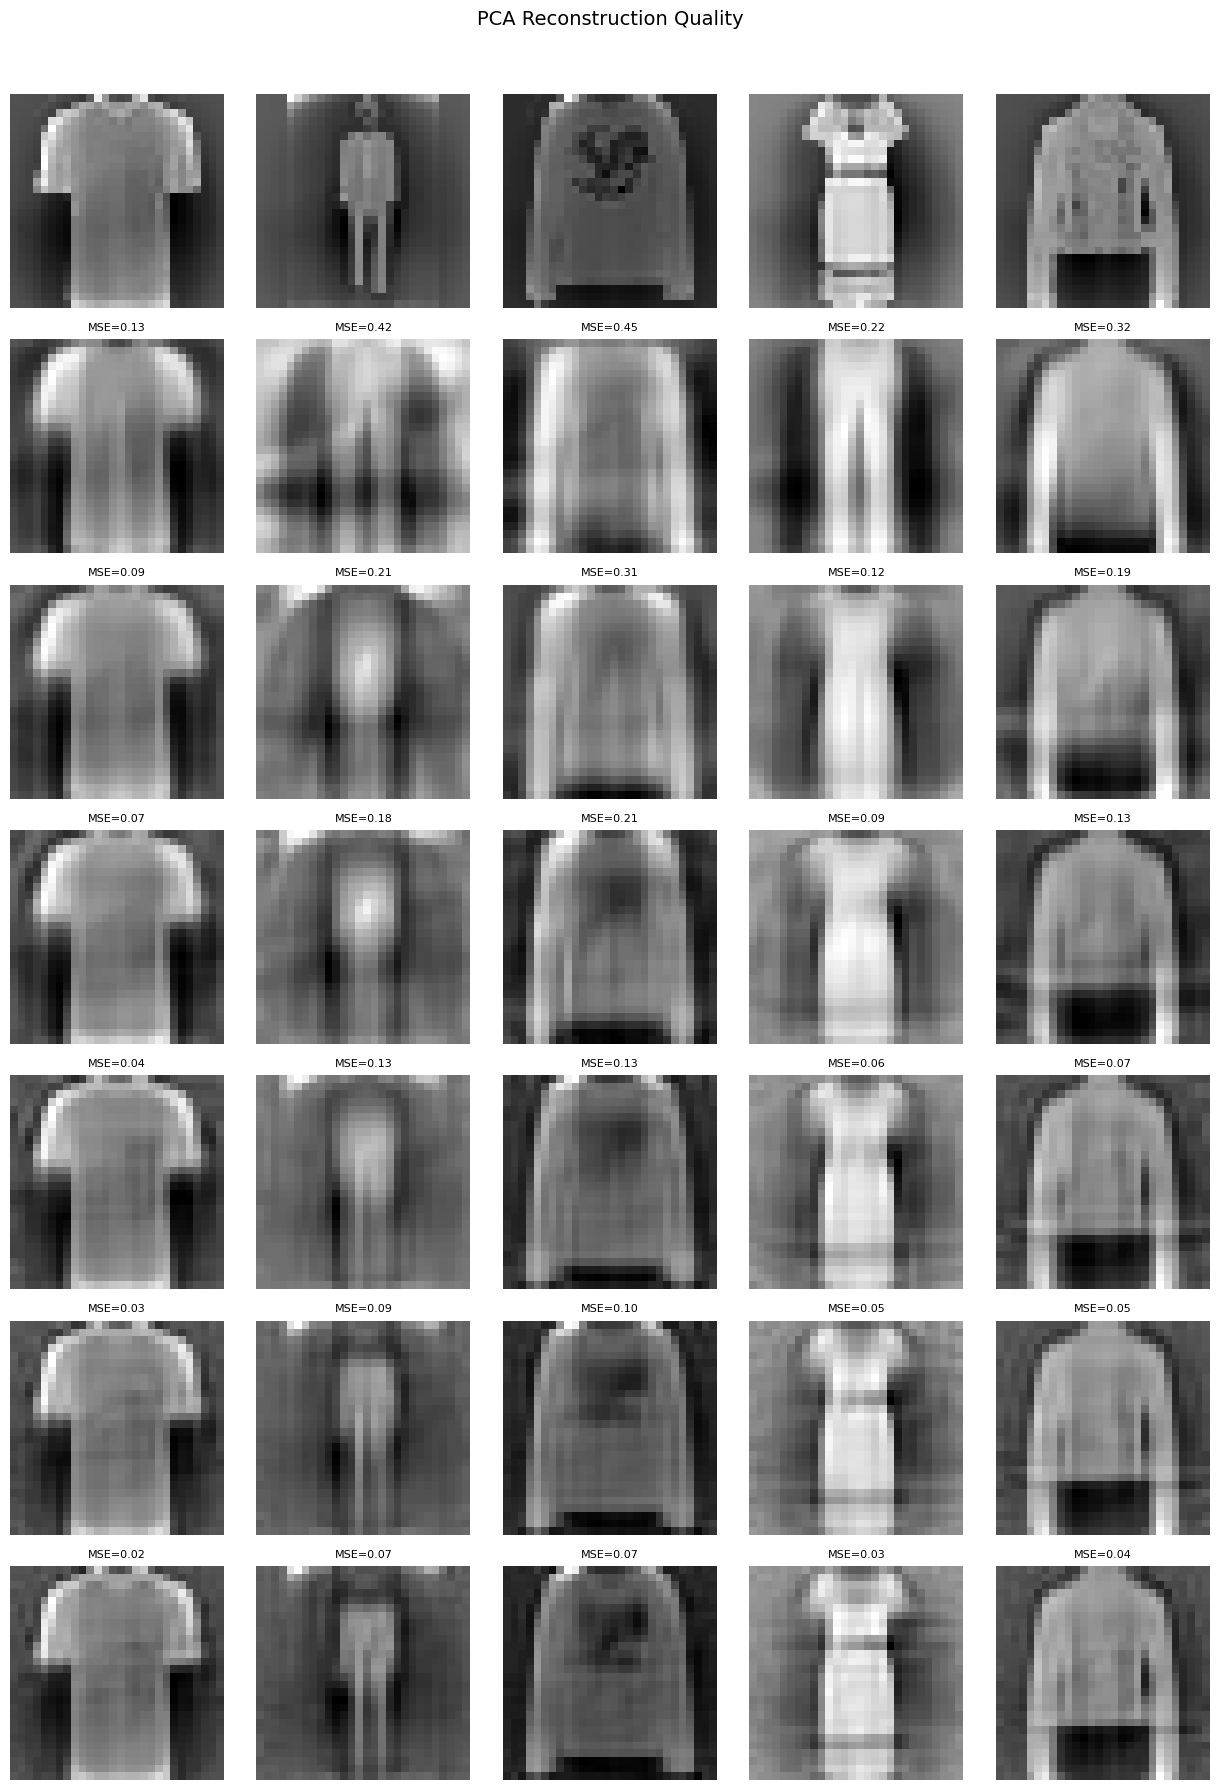

[4/8] Reconstruction quality
  n= 10: MSE=0.3077
  n= 25: MSE=0.1846
  n= 50: MSE=0.1361
  n=100: MSE=0.0886
  n=150: MSE=0.0623
  n=200: MSE=0.0462


In [4]:
# Step 4: Reconstruction at different component counts

from collections import OrderedDict

# Pick 5 diverse test samples (same seed = same indices across frameworks)
np.random.seed(RANDOM_STATE)
sample_indices = []
for cls in range(5):
    cls_idx = np.where(y_test == cls)[0]
    sample_indices.append(np.random.choice(cls_idx))

# TF tensors for transform, but originals as numpy for plotting
originals_tf = tf.gather(X_test, sample_indices)
originals_np = originals_tf.numpy()

# Reconstruct at each component count
reconstructions = OrderedDict()
for n_comp in N_COMPONENTS_LIST:
    pca_n = PCATf(n_components=n_comp)
    pca_n.fit(X_train)
    X_reduced = pca_n.transform(originals_tf)
    X_recon = pca_n.inverse_transform(X_reduced)
    reconstructions[n_comp] = X_recon.numpy()

plot_reconstruction_grid(originals_np, reconstructions, IMAGE_SHAPE, n_samples=5,
                         save_path=f'{RESULTS_DIR}/reconstruction_grid.png')

print("=" * 60)
print("[4/8] Reconstruction quality")
print("=" * 60)
for n_comp, recon in reconstructions.items():
    mse = np.mean((originals_np - recon) ** 2)
    print(f"  n={n_comp:>3}: MSE={mse:.4f}")

[5/8] Component sweep — KNN accuracy at each n_components
  n= 10: accuracy=0.8014  (784 → 10, 1.3%)
  n= 25: accuracy=0.8385  (784 → 25, 3.2%)
  n= 50: accuracy=0.8506  (784 → 50, 6.4%)
  n=100: accuracy=0.8575  (784 → 100, 12.8%)
  n=150: accuracy=0.8599  (784 → 150, 19.1%)
  n=200: accuracy=0.8598  (784 → 200, 25.5%)


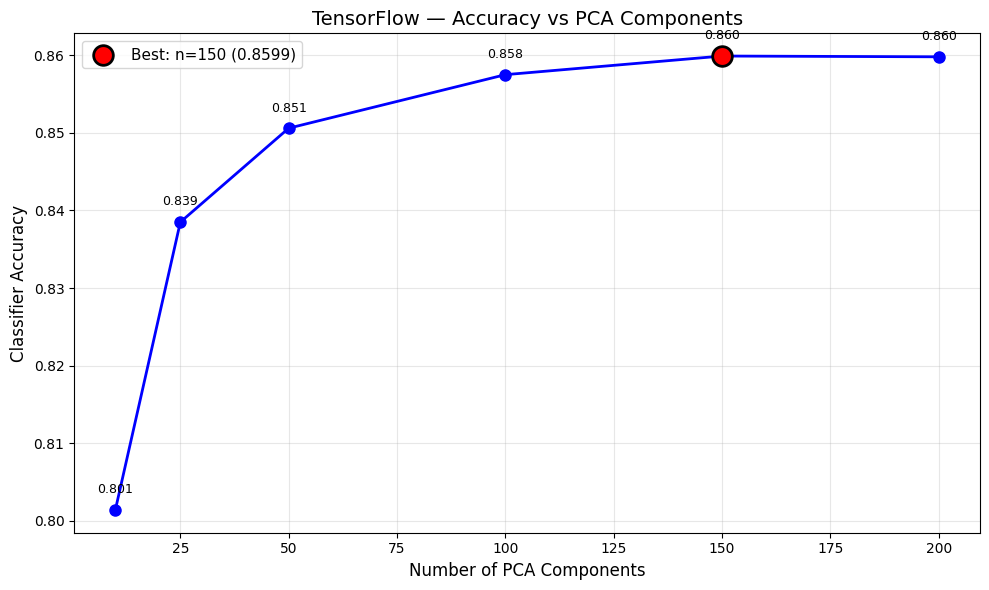

In [5]:
# Step 5: Downstream classifier accuracy vs components

# KNN runs on CPU (sklearn) — .numpy() at boundary for KNN
print("=" * 60)
print("[5/8] Component sweep — KNN accuracy at each n_components")
print("=" * 60)

accuracies = []
for n_comp in N_COMPONENTS_LIST:
    pca_n = PCATf(n_components=n_comp)
    pca_n.fit(X_train)
    X_train_pca = pca_n.transform(X_train).numpy()
    X_test_pca = pca_n.transform(X_test).numpy()

    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(X_train_pca, y_train)
    acc = knn.score(X_test_pca, y_test)
    accuracies.append(acc)
    print(f"  n={n_comp:>3}: accuracy={acc:.4f}  (784 → {n_comp}, {n_comp/784*100:.1f}%)")

plot_component_accuracy(N_COMPONENTS_LIST, accuracies, FRAMEWORK,
                        save_path=f'{RESULTS_DIR}/component_accuracy.png')

In [6]:
# Step 6: Eager vs tf.function Showcase (TF-exclusive)
"""
TensorFlow's tf.function compiles Python code into a static
computation graph, enabling optimizations like operation fusion
and XLA compilation. This cell benchmarks whether graph-mode
compilation speeds up PCA's linear algebra ops (covariance +
eigendecomposition) compared to default eager execution.

For PCA, the bottleneck is tf.linalg.eigh on a 784×784 matrix —
a single LAPACK call that's already optimized. Graph mode helps
most when there are many small ops to fuse, so we may see
minimal speedup here.
"""

BEST_N = 150
import time

print("=" * 60)
print("[6/8] Eager vs tf.function Showcase")
print("=" * 60)

# Define PCA fit as a standalone function for tf.function wrapping
def pca_fit_eager(X, n_components):
    """PCA fit in eager mode — same ops as PCATf.fit()."""
    n = tf.cast(tf.shape(X)[0], tf.float32)
    mean = tf.reduce_mean(X, axis=0)
    X_centered = X - mean
    cov = tf.transpose(X_centered) @ X_centered / n
    eigenvalues, eigenvectors = tf.linalg.eigh(cov)
    idx = tf.argsort(eigenvalues, direction='DESCENDING')
    eigenvalues = tf.gather(eigenvalues, idx)
    eigenvectors = tf.gather(eigenvectors, idx, axis=1)
    components = tf.transpose(eigenvectors[:, :n_components])
    return components, eigenvalues, mean

# Wrap with tf.function for graph compilation
@tf.function
def pca_fit_graph(X, n_components):
    """Same PCA fit, but traced into a TF graph."""
    return pca_fit_eager(X, n_components)

N_RUNS = 50

# Eager benchmark
print(f"\n[1/3] Eager mode ({N_RUNS} runs)...")

# Warmup
for _ in range(3):
    pca_fit_eager(X_train, BEST_N)

eager_times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    pca_fit_eager(X_train, BEST_N)
    eager_times.append(time.perf_counter() - t0)

eager_mean = np.mean(eager_times) * 1000  # ms
eager_std = np.std(eager_times) * 1000
print(f"  Mean: {eager_mean:.2f} ms (±{eager_std:.2f} ms)")

# Graph benchmark
print(f"\n[2/3] tf.function graph mode ({N_RUNS} runs)...")

# Warmup (first call triggers tracing)
for _ in range(3):
    pca_fit_graph(X_train, BEST_N)

graph_times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    pca_fit_graph(X_train, BEST_N)
    graph_times.append(time.perf_counter() - t0)

graph_mean = np.mean(graph_times) * 1000  # ms
graph_std = np.std(graph_times) * 1000
print(f"  Mean: {graph_mean:.2f} ms (±{graph_std:.2f} ms)")

# Comparison
speedup = eager_mean / graph_mean
print(f"\n[3/3] Comparison:")
print(f"  Eager:       {eager_mean:.2f} ms")
print(f"  tf.function: {graph_mean:.2f} ms")
print(f"  Speedup:     {speedup:.2f}x {'(graph faster)' if speedup > 1 else '(eager faster)'}")

# Verify results match
comp_eager, eig_eager, _ = pca_fit_eager(X_train, BEST_N)
comp_graph, eig_graph, _ = pca_fit_graph(X_train, BEST_N)
eigenval_diff = tf.reduce_max(tf.abs(eig_eager - eig_graph)).numpy()
print(f"\n  Eigenvalue difference (eager vs graph): {eigenval_diff:.2e}")
print(f"\n  Note: PCA is dominated by a single eigh LAPACK call.")
print(f"  tf.function helps more with many small ops to fuse.")

[6/8] Eager vs tf.function Showcase

[1/3] Eager mode (50 runs)...
  Mean: 175.30 ms (±4.70 ms)

[2/3] tf.function graph mode (50 runs)...
  Mean: 161.34 ms (±3.00 ms)

[3/3] Comparison:
  Eager:       175.30 ms
  tf.function: 161.34 ms
  Speedup:     1.09x (graph faster)

  Eigenvalue difference (eager vs graph): 3.43e-05

  Note: PCA is dominated by a single eigh LAPACK call.
  tf.function helps more with many small ops to fuse.


In [7]:
# Step 7: Performance Benchmarks

# Training benchmark: fit PCA on CPU TF tensors
pca_bench = PCATf(n_components=BEST_N)

with track_performance() as perf:
    pca_bench.fit(X_train)

print("=" * 60)
print("[7/8] Performance Benchmarks")
print("=" * 60)
print(f"\n  Training (PCA fit, n={BEST_N}):")
print(f"    Time:        {perf['time']:.4f} s")
print(f"    Memory:      {perf['memory']:.2f} MB")

# Inference benchmark: transform, .numpy() at boundary
def transform_fn(X_np):
    X_tf = tf.constant(X_np, dtype=tf.float32)
    return pca_bench.transform(X_tf).numpy()

inference_result = track_inference(transform_fn, X_test_np, n_runs=100)

print(f"\n  Inference (transform):")
print(f"    Per sample:  {inference_result['per_sample_us']:.2f} µs")
print(f"    Batch ({X_test_np.shape[0]:,}): {inference_result['total_time']:.2f} ms")

# Model size — components + mean as numpy arrays
model_dict = {
    'components': pca_bench.components_.numpy(),
    'mean': pca_bench.mean_.numpy(),
    'explained_variance': pca_bench.explained_variance_.numpy(),
    'explained_variance_ratio': pca_bench.explained_variance_ratio_.numpy()
}
model_size = get_model_size(model_dict, framework='numpy')
print(f"\n  Model size:    {model_size / 1024:.2f} KB")
print(f"    Components matrix: {tuple(pca_bench.components_.shape)}")

[7/8] Performance Benchmarks

  Training (PCA fit, n=150):
    Time:        0.1709 s
    Memory:      0.02 MB

  Inference (transform):
    Per sample:  0.93 µs
    Batch (10,000): 0.01 ms

  Model size:    463.61 KB
    Components matrix: (150, 784)


In [8]:
# Step 8: Save results + cross-framework comparison

# Reconstruction error on test set
X_test_reduced = pca_bench.transform(X_test)
X_test_recon = pca_bench.inverse_transform(X_test_reduced)
recon_mse = tf.reduce_mean((X_test - X_test_recon) ** 2).numpy()

# PCA intrinsic metrics
test_metrics = {
    'explained_variance_ratio': float(pca_bench.explained_variance_ratio_.numpy().sum()),
    'reconstruction_mse': float(recon_mse)
}

# Best accuracy from Cell 5 sweep (n=150)
pca_acc = accuracies[N_COMPONENTS_LIST.index(BEST_N)]

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='PCA',
    test_metrics=test_metrics,
    perf=perf,
    inference_stats=inference_result,
    model_size=model_size,
    n_components=BEST_N,
    downstream_knn_accuracy=float(pca_acc)
)

print("=" * 60)
print("[8/8] Save Results")
print("=" * 60)

# Save locally
save_results(results, save_dir=RESULTS_DIR)

# Add to cross-framework comparison
add_result('pca', results)

# Print comparison
print_comparison('pca')

[8/8] Save Results
    Results saved to: results\metrics.json
    Added 'TensorFlow' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\pca.json
    Frameworks recorded: 4/4

CROSS-FRAMEWORK COMPARISON: PCA
Metric                          Scikit-Learn  No-Framework       PyTorch    TensorFlow
--------------------------------------------------------------------------------------
model                                    PCA           PCA           PCA           PCA
training_time                         0.19 s        0.23 s        0.11 s        0.17 s
inference_time_per_sample_us         0.52 µs       0.89 µs       0.39 µs       0.93 µs
model_size_bytes                    464.2 KB      463.6 KB      463.6 KB      463.6 KB
peak_memory_mb                      11.74 MB     191.18 MB       0.00 MB       0.02 MB
explained_variance_ratio              0.9085        0.9085        0.9085        0.9085
reconstruction_mse                    0.0951        0.0951      